## More on Distribtuion Plots

In [2]:
import seaborn as sns

In [3]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Group-by `island`: Normalized histogram statistics

When the subsets have **unequal** numbers of observations (notice the left and middle between this and the histogram below it), comparing their distributions in terms of counts may not be ideal.

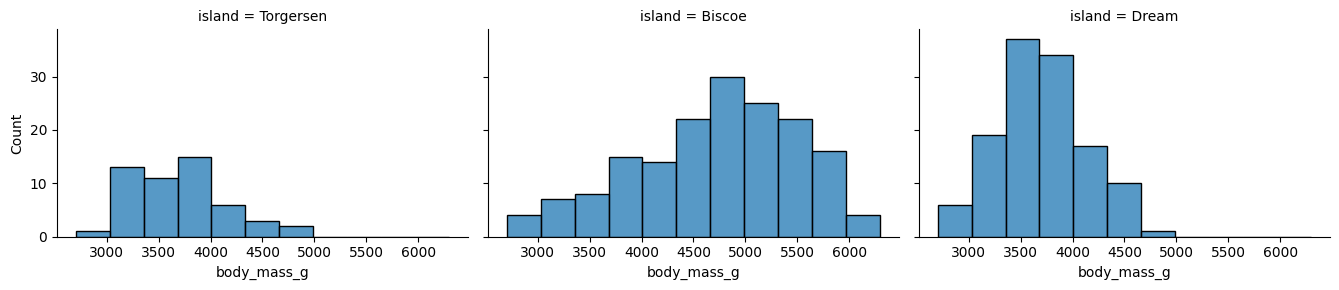

In [ ]:
sns.displot(
    penguins, x="body_mass_g", col="island",
    aspect=1.5, height=3,
)

One solution is to normalize the counts using the `stat` parameter. By default, however, the normalization is applied to the entire distribution, so this simply rescales the height of the bars. By setting `common_norm=False`, each subset will be **normalized independently**:

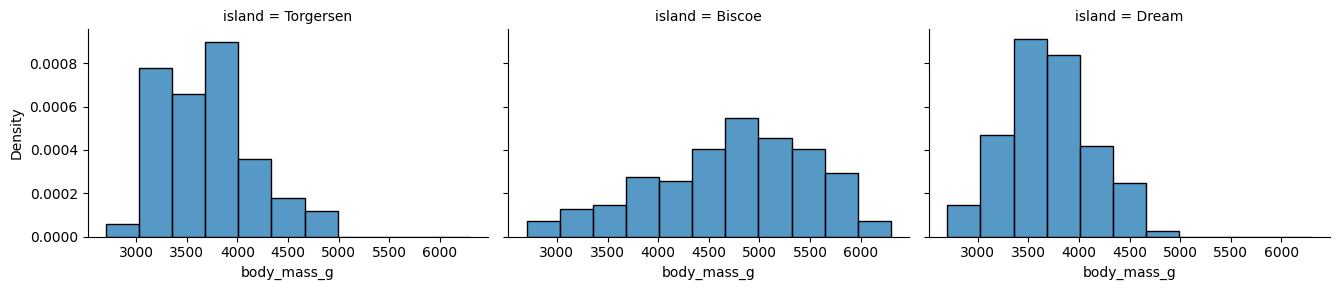

In [ ]:
sns.displot(
    penguins, x="body_mass_g", col="island",
    aspect=1.5, height=3,
    stat="density",    # stat="density"; Adjust for unequal counts
    common_norm=False, # common_norm=False; to normalize each subset independently
)

- Density normalization scales the bars so that **their areas sum to 1**. As a result, the density axis is not directly interpretable.
- Another option is to normalize the bars so that **their heights sum to 1**. This makes most sense when the variable is discrete, but it is an option for all histograms:

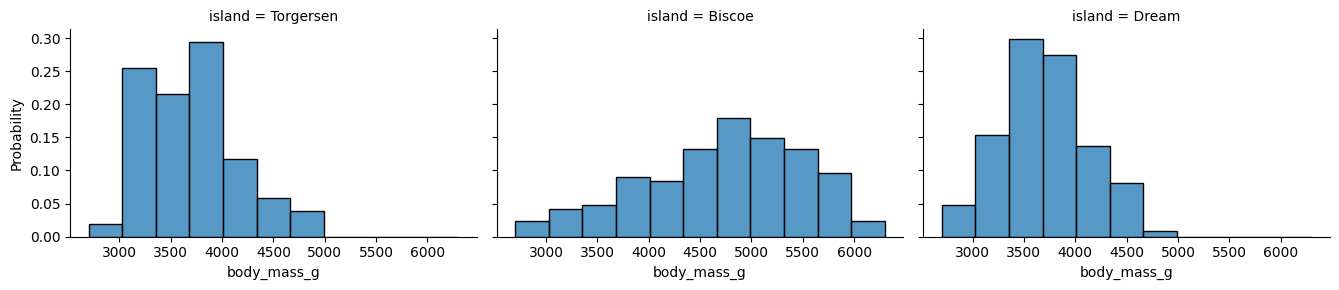

In [ ]:
sns.displot(
    penguins, x="body_mass_g", col="island",
    aspect=1.5, height=3,
    stat="probability", # bar heights sum up to 1
    common_norm=False
)

## Empirical cumulative distributions

A third option for visualizing distributions computes the “empirical cumulative distribution function” (ECDF). This plot draws a monotonically-increasing curve through each datapoint such that **the height of the curve reflects the proportion of observations with a smaller value**:

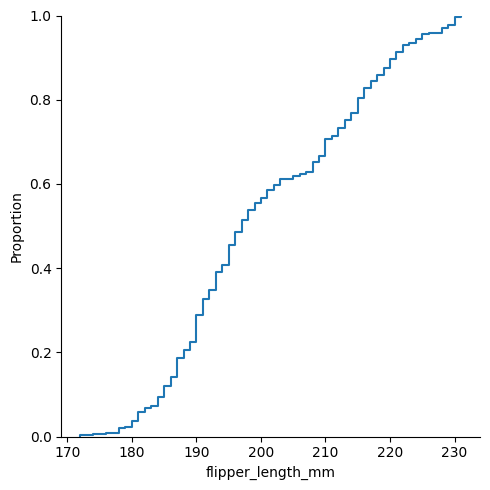

In [ ]:
sns.displot(penguins, x="flipper_length_mm", kind="ecdf")

We can see that the median (50th percentile) is around 198. Let's calculate it to verify:

In [ ]:
penguins['flipper_length_mm'].median()

np.float64(197.0)

.. and the 99th percentile is around 228. Let's verify:

In [ ]:
penguins['flipper_length_mm'].quantile(0.99)

np.float64(230.0)

The ECDF plot has two key advantages.

- Firstly, unlike the histogram or KDE, it directly represents each datapoint. That means there is no bin size or smoothing parameter to consider.
- Secondly, because the curve is monotonically increasing, it is well-suited for comparing multiple distributions:

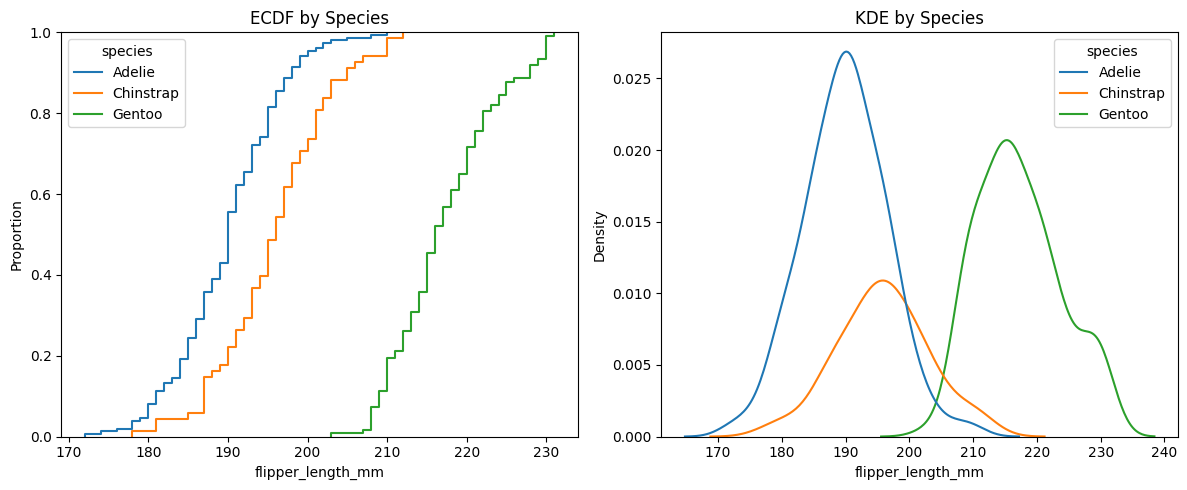

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.ecdfplot(data=penguins, x="flipper_length_mm", hue="species", ax=axes[0])
axes[0].set_title("ECDF by Species")

sns.kdeplot(data=penguins, x="flipper_length_mm", hue="species", ax=axes[1])
axes[1].set_title("KDE by Species")

plt.tight_layout()
plt.show()

The major downside to the ECDF plot is that it represents the shape of the distribution less intuitively than a histogram or density curve. Consider how the bimodality of flipper lengths is immediately apparent in the histogram, but to see it in the ECDF plot, you must look for varying slopes. **Nevertheless, with practice, you can learn to answer all of the important questions about a distribution by examining the ECDF, and doing so can be a powerful approach**.

---

References:

- https://seaborn.pydata.org/tutorial/distributions.html